<a href="https://colab.research.google.com/github/disha-002/DeepLearning/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [208]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

In [209]:
torch.manual_seed(0)
random.seed(42)

In [210]:
df = pd.read_csv('/content/Electric_Production.csv')
values = df['Value'].values

In [211]:
mean = values.mean()
std = values.std()
values = (values - mean)/std

I have chose LSTM as my model because the dependency length is long.

The data size is small.

there is no requirement of interpretability and speed.

Since the data size is small I am not using transformer and since the dependency length is large I am preferring LSTM.

In [212]:
import numpy as np
import torch

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 90
X, y = create_sequences(values, seq_length)

X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(y, dtype=torch.float32)

In [213]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [214]:
lstm = nn.LSTM(input_size=1,hidden_size=100,batch_first=True)
fc=nn.Linear(100,1)


In [215]:
optimizer = torch.optim.Adam(list(lstm.parameters()) + list(fc.parameters()), lr=0.001)
loss_fn = nn.MSELoss()

train_losses = []
epochs = 1001

for epoch in range(epochs):
    out, _ = lstm(X_train)
    out = out[:, -1, :]
    out = fc(out)

    loss = loss_fn(out.squeeze(), y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if epoch % 100 == 0:
      print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.5868905186653137
Epoch 101, Loss: 0.25548648834228516
Epoch 201, Loss: 0.046379100531339645
Epoch 301, Loss: 0.03675146400928497
Epoch 401, Loss: 0.03624418377876282
Epoch 501, Loss: 0.027036098763346672
Epoch 601, Loss: 0.02393820323050022
Epoch 701, Loss: 0.034897610545158386
Epoch 801, Loss: 0.022380517795681953
Epoch 901, Loss: 0.019163407385349274
Epoch 1001, Loss: 0.017223799601197243


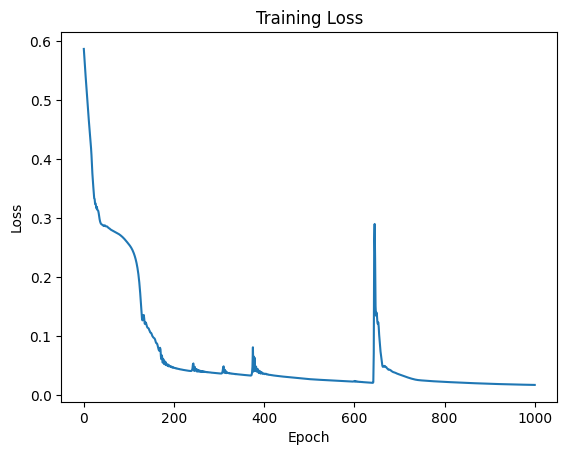

In [216]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Failure Prediction 1

Even though large window sizes reduced the mean square error but still there was instability in the training because of the computational complexity.

Failure Prediction 2

the model suffers from long horizon forecasting because error accumulates across successive timesteps.

Failure Prediction 3

since the electricity consumtion data changes with seasonal , policy and demand changes , the future data can differ from the training data.

In [217]:
lstm.eval()

with torch.no_grad():
    out, _ = lstm(X_test)
    out = out[:, -1, :]
    preds = fc(out).squeeze()

In [218]:
import numpy as np

y_true = y_test.numpy()
y_pred = preds.numpy()

mse = np.mean((y_true - y_pred)**2)
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

MSE: 0.050149266
MAE: 0.17481749
RMSE: 0.22394031


In [219]:
if seq_length == 45:
    lstm_45 = mse
elif seq_length == 90:
    lstm_90 = mse
elif seq_length == 180:
    lstm_180 = mse

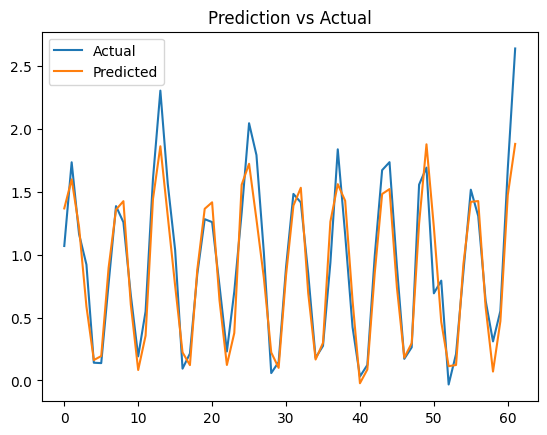

In [220]:
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

The model underestimates extremely high value because LSTM tends to learn domainant repeating patterns more strongly than sudden changes.

The model does not fluctuate exactly as the actual data because of minimizing mse that encourages stable learning over patterns and not matching every abrupt variation.



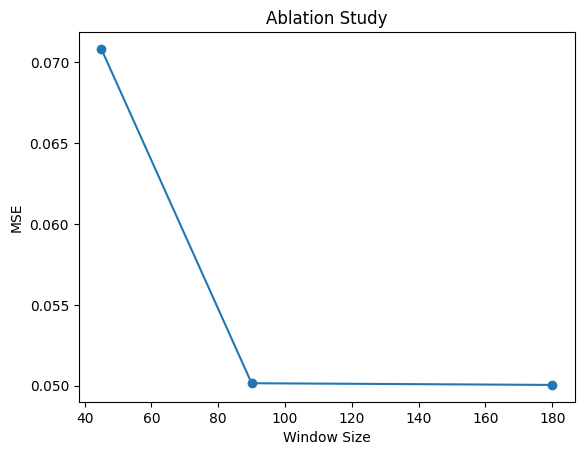

In [222]:
seqs = [45, 90, 180]

mse_vals = [lstm_45, lstm_90, lstm_180]

plt.plot(seqs, mse_vals, marker='o')

plt.xlabel("Window Size")
plt.ylabel("MSE")
plt.title("Ablation Study")
plt.show()